# K-Means - Model Development Workflow (Mall Customer Segmentation)

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Frame a clustering task around a business question
2. Explore the data before clustering (distributions + pairwise scatter)
3. Process correctly for distance models (**StandardScaler is mandatory**)
4. Choose k with inertia AND silhouette side-by-side
5. Fit the final model, build a **segment profile table**, name segments
   like a marketer, and visualize them with centroid stars

Business question: *a shopping-mall marketing team wants to split its 200
loyalty-card members into actionable groups - whom do we target with premium
offers, whom with discounts?*

### Setup cell


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # inline plots in Jupyter
except NameError:
    pass                                                   # plain-python fallback

import numpy as np                  # arrays + seeding
import pandas as pd                 # tables & profiling
import matplotlib.pyplot as plt     # plotting
import seaborn as sns               # statistical styling

from sklearn.preprocessing import StandardScaler       # THE scaling step
from sklearn.cluster import KMeans                     # our model
from sklearn.metrics import silhouette_score           # k-selection judge

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Resolve course data dir by walking up to '02_machine_learning';
    download <fname> from <url> once if absent."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():    # course root found
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("could not locate 02_machine_learning folder")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)         # download-once helper
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")


### 1. Load & explore

⚠️ EDA before clustering is not optional: you need to know ranges, skew, and
whether obvious groups exist - otherwise you cannot judge whether the final
clusters make sense.

In [2]:
mall = pd.read_csv(get_data("mall_customers.csv", MALL_URL))
mall = mall.rename(columns={"Genre": "Gender"})          # clearer column name
print(mall.shape)
mall.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
mall.describe().round(1)      # ranges differ wildly -> scaling will be needed

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.5,38.8,60.6,50.2
std,57.9,14.0,26.3,25.8
min,1.0,18.0,15.0,1.0
25%,50.8,28.8,41.5,34.8
50%,100.5,36.0,61.5,50.0
75%,150.2,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


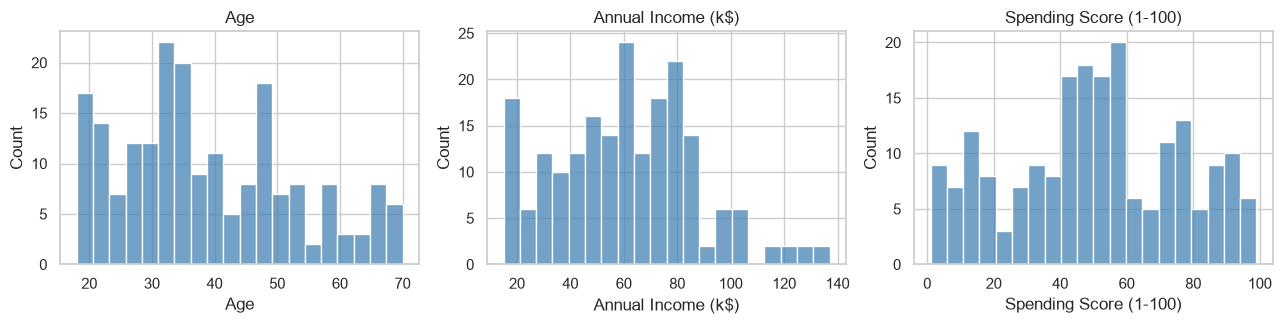

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))        # distribution trio
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(mall[col], bins=20, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Income is roughly uniform-ish with a spike near ~50k and ~80k; spending score
is centered around 50 with fat shoulders. No brutal outliers - safe to proceed.

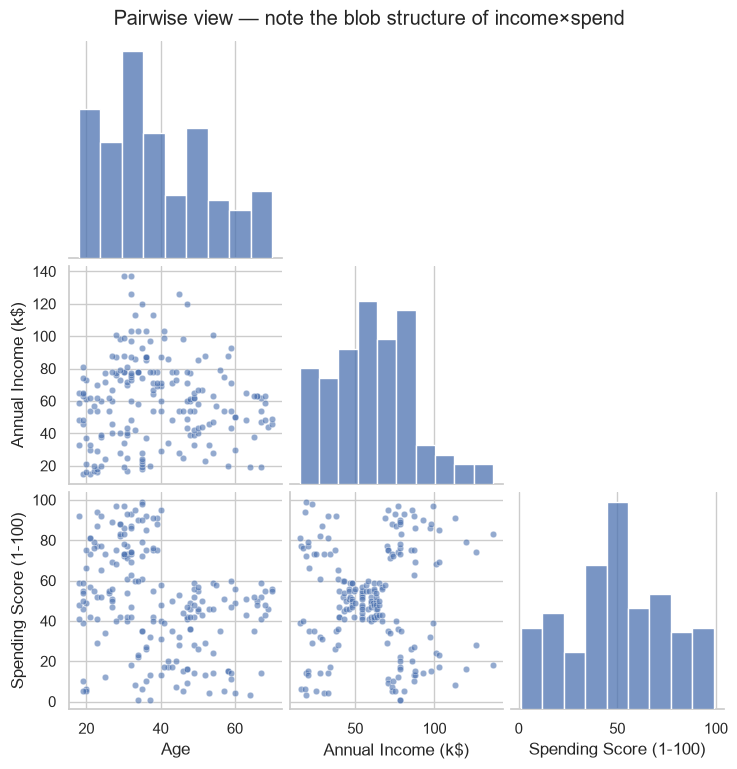

In [5]:
sns.pairplot(mall[["Age", "Annual Income (k$)", "Spending Score (1-100)"]],
             corner=True, plot_kws=dict(s=22, alpha=0.6, edgecolor="white"))
plt.suptitle("Pairwise view - note the blob structure of income×spend",
             y=1.02)
plt.show()

The **income × spend** panel shows visible clumps - five-ish islands. Age
looks unstructured against both, so we cluster on income+spend and KEEP age
purely as a profiling variable (does a segment skew young?).

### 2. Processing: select features + scale

Distance-based models compare feature magnitudes; unscaled, "Annual Income"
(15-137) would shout over "Spending Score" (1-99)… actually those look close,
but the principle stands: StandardScaler puts both on mean-0/std-1 footing so
neither axis dominates arbitrarily.

In [6]:
feat_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()                                 # z = (x - mean) / std
X_scaled = scaler.fit_transform(mall[feat_cols])          # fit ONLY on features used
X_scaled[:5].round(2)                                     # sanity peek

array([[-1.74, -0.43],
       [-1.74,  1.2 ],
       [-1.7 , -1.72],
       [-1.7 ,  1.04],
       [-1.66, -0.4 ]])

### 3. Modeling: choose k (inertia + silhouette together)

Inertia falls forever, so we pair it with **mean silhouette** (higher =
better-separated clusters; details in module 03). Read the two panels as a
team: elbow location + silhouette peak should agree.

In [7]:
ks = range(2, 11)                                          # try k = 2..10
inertias, sils = [], []
for k in ks:                                               # fresh model per k
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)                           # elbow fuel
    sils.append(silhouette_score(X_scaled, km.labels_))    # separation quality

best_k = list(ks)[int(np.argmax(sils))]                    # k with best silhouette
print(f"silhouette favors k={best_k} ({max(sils):.3f})")

silhouette favors k=5 (0.555)


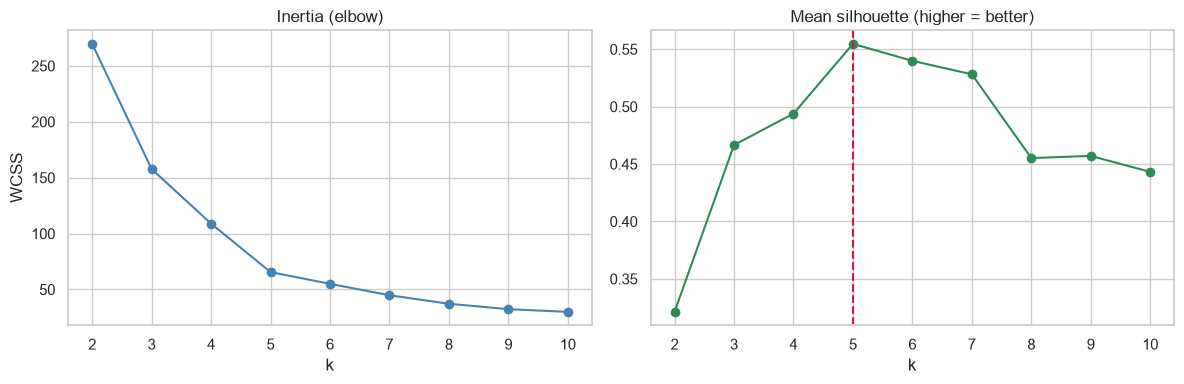

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))       # side-by-side judges
ax1.plot(list(ks), inertias, marker="o", color="steelblue")
ax1.set_title("Inertia (elbow)"); ax1.set_xlabel("k"); ax1.set_ylabel("WCSS")
ax2.plot(list(ks), sils, marker="o", color="seagreen")
ax2.axvline(best_k, ls="--", color="crimson")               # mark the winner
ax2.set_title("Mean silhouette (higher = better)")
ax2.set_xlabel("k")
plt.tight_layout(); plt.show()

Both signals point to **k = 5**: elbow bends there and silhouette peaks.
(Business reality bonus: five segments is also a number a marketing team can
actually staff campaigns for.)

### 4. Final model + segment profiles


In [9]:
km_final = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X_scaled)
mall["cluster"] = km_final.labels_                          # attach cluster ids
mall["cluster"].value_counts().sort_index()                 # sizes feel balanced?

cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Profile table: mean demographics per cluster + counts. We aggregate on RAW


In [ ]:
# units (not scaled) so numbers stay readable for humans.
profile = (mall.groupby("cluster")
               .agg(size=("cluster", "size"),
                    age_mean=("Age", "mean"),
                    income_mean=("Annual Income (k$)", "mean"),
                    spend_mean=("Spending Score (1-100)", "mean"))
               .round(1))

def segment_name(row):
    """Turn numeric means into a marketing-friendly label using simple domain
    cut-offs on raw units (income in k$, score out of 100)."""
    inc = ("high-income" if row.income_mean >= 70 else
           "mid-income" if row.income_mean >= 40 else "low-income")
    spd = ("big-spender" if row.spend_mean >= 60 else
           "moderate" if row.spend_mean >= 40 else "careful")
    return f"{inc} {spd}"

profile["segment"] = profile.apply(segment_name, axis=1)    # auto-name each row
profile


💡 Cluster IDs (0-4) are arbitrary - the `segment` column is what humans
read. In a real deliverable you would freeze this mapping into a dict so
dashboards never break when sklearn reshuffles ids on retrain.

### 5. Visualize segments with centroid stars

We plot in ORIGINAL units (inverse-transforming the centroids back) so the
chart speaks business language while the model ran in scaled space.

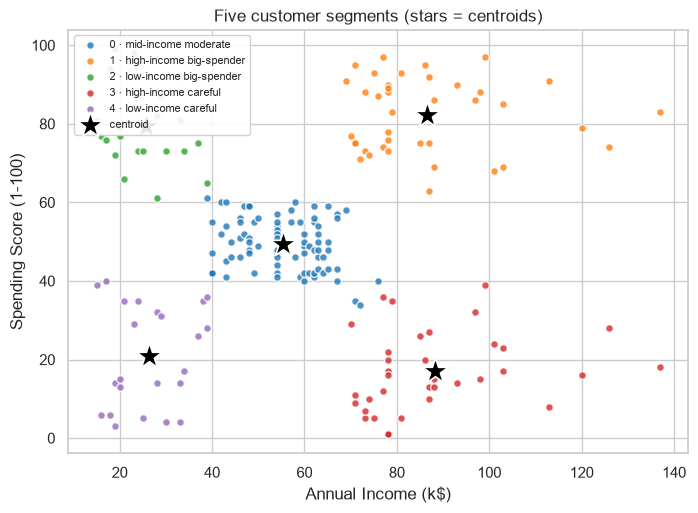

In [11]:
centers_raw = scaler.inverse_transform(km_final.cluster_centers_)  # back to k$/score

fig, ax = plt.subplots(figsize=(8, 5.5))
palette = sns.color_palette("tab10", 5)
for c in sorted(mall["cluster"].unique()):                  # one scatter per cluster
    sub = mall[mall["cluster"] == c]
    ax.scatter(sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               s=30, alpha=0.8, color=palette[c], edgecolor="white",
               label=f"{c} · {profile.loc[c, 'segment']}")
ax.scatter(centers_raw[:, 0], centers_raw[:, 1],            # centroid stars
           marker="*", s=380, c="black", edgecolors="white",
           linewidths=1.2, zorder=5, label="centroid")
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score (1-100)")
ax.set_title("Five customer segments (stars = centroids)")
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
plt.show()

### Summary

- Workflow: **question → EDA → scale → choose k (inertia + silhouette) →
  fit → profile → visualize → recommend**.
- Scaling was non-negotiable because K-Means compares Euclidean distances.
- Five segments emerged: e.g., high-income big-spenders (prime targets),
  high-income careful shoppers (persuadable with value messaging),
  low-income big-spenders (small basket, high enthusiasm).
- ⚠️ Limitations: two-feature toy geometry, k chosen visually, and cluster
  ≠ truth - validate on next quarter's campaign response before betting
  budget on these names.